<a href="https://colab.research.google.com/github/AartiP87/assignment-01-Bitsom_BA_2511841/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the player.",
    "The team won the cricket match by chasing a big target.",

    # Cooking
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking a cake requires precise measurements and timing.",
    "The recipe includes spices that enhance the flavor of the dish.",

    # Cybersecurity
    "Strong passwords are essential to protect online accounts.",
    "A firewall helps prevent unauthorized access to a network.",
    "Phishing attacks trick users into revealing sensitive information.",
    "Encryption ensures that data remains secure during transmission."
]

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix:\n")
print(similarity_matrix)

Similarity Matrix:

[[ 1.0000002   0.3750924   0.6002288  -0.02327408  0.12859863  0.00190748
  -0.01713319 -0.0076849  -0.00909402  0.01084722]
 [ 0.3750924   1.          0.4120525   0.07784998  0.05790116  0.05610967
  -0.04559646  0.07476498  0.06045483  0.04036562]
 [ 0.6002288   0.4120525   1.         -0.04998939  0.07711852  0.0328288
  -0.04526119  0.07646334  0.03427353  0.06618011]
 [-0.02327408  0.07784998 -0.04998939  0.9999999   0.16247186  0.4753055
  -0.03763476  0.02036584  0.01886268  0.02327671]
 [ 0.12859863  0.05790116  0.07711852  0.16247186  1.          0.14478973
  -0.00726783  0.04343582  0.13040419  0.08746829]
 [ 0.00190748  0.05610967  0.0328288   0.4753055   0.14478973  1.0000002
   0.00541449  0.03081198  0.12554088  0.00179966]
 [-0.01713319 -0.04559646 -0.04526119 -0.03763476 -0.00726783  0.00541449
   1.0000002   0.38466212  0.36112732  0.32784095]
 [-0.0076849   0.07476498  0.07646334  0.02036584  0.04343582  0.03081198
   0.38466212  0.99999976  0.24790

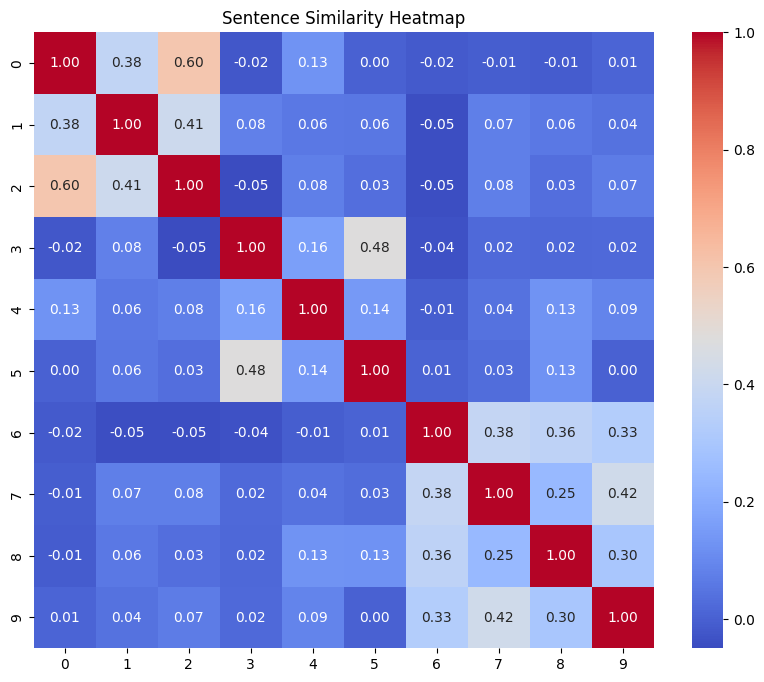

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679

Sentence: The team won the cricket match by chasing a big target.
Similarity Score: 0.5323

